In [ ]:
!unzip train.zip

In [ ]:
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

In [ ]:
# load color images

import os

orig_images = []

for file in os.listdir("train"):
  image_file = os.path.join("train", file)
  if image_file.endswith(".jpg"):
    image = keras.utils.load_img(image_file, target_size=(150, 100))
    orig_images.append(image)
orig_images = np.array(orig_images)

In [ ]:
orig_images.shape

(200, 150, 100, 3)

In [ ]:
# plot images

def plot_images(images, color_mode='viridis'):
  plt.figure(figsize=(8, 8))

  for k in range(25):
    plt.subplot(5, 5, k + 1)
    plt.imshow(images[k], cmap=color_mode)
    plt.axis('off')

In [ ]:
# normalize values to [0, 1]
orig_images = orig_images / 255.0

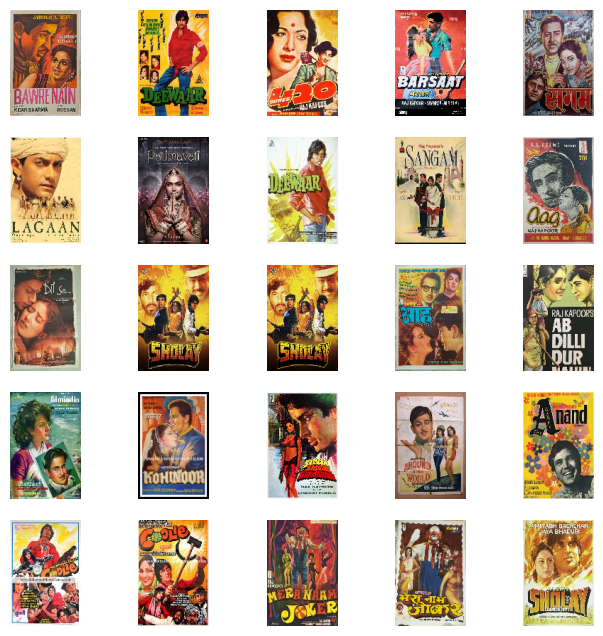

In [ ]:
plot_images(orig_images)

In [ ]:
# convert images to grayscale
def add_grayscale(images):
  gray_images = np.dot(images[...,:3], [0.299, 0.587, 0.114])
  return gray_images

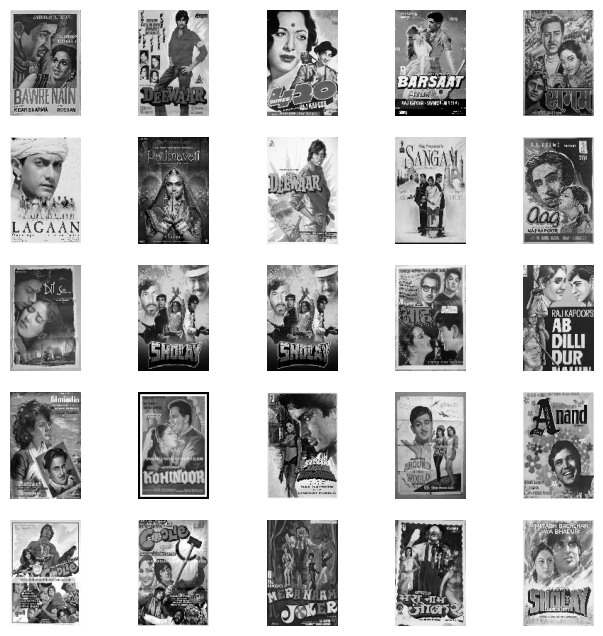

In [ ]:
# create grayscale images
gray_images = add_grayscale(orig_images)
plot_images(gray_images, color_mode="gray")

In [ ]:
gray_images.shape

(200, 150, 100)

In [ ]:
# create dummy RGB by copying grayscale values across 3 channels
def add_color(images):
  color_images = np.stack((images,)*3, axis=-1)
  return color_images

In [ ]:
# create grayscale images with 3 channels
color_images = add_color(gray_images)
color_images.shape

(200, 150, 100, 3)

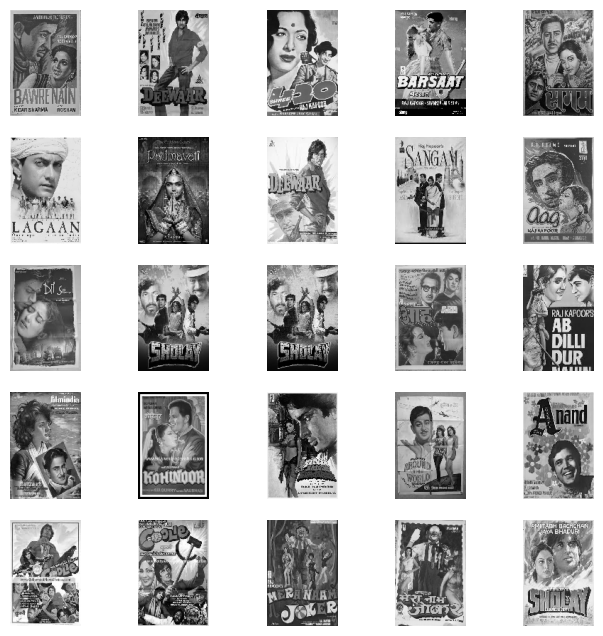

In [ ]:
plot_images(color_images)

In [ ]:
# generator model to restore original from noisy images

def build_generator():
  inputs = keras.Input(shape=(150, 100, 3))

  x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(inputs)
  x = layers.Dropout(0.2)(x)

  x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
  x = layers.Dropout(0.2)(x)

  x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
  x = layers.Dropout(0.2)(x)

  outputs = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid')(x)

  model = keras.Model(inputs, outputs)
  return model

In [ ]:
generator = build_generator()
generator.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 150, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 150, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 100, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,379 (302.26 KB)

 Trainable params: 77,379 (302.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
generator.compile(optimizer='adam', loss='mse')
generator.fit(color_images, orig_images, epochs=15)

In [ ]:
# load test image
test_image = keras.utils.load_img("sample.jpg", target_size=(150, 100))
test_image = np.array(test_image) / 255.0
test_gray = np.dot(test_image[...,:3], [0.299, 0.587, 0.114])
test_color = np.stack((test_gray,)*3, axis=-1)

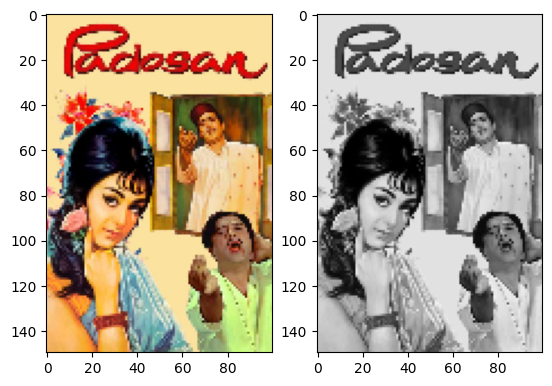

In [ ]:
# plot sample image and noisy version side by side
plt.subplot(1, 2, 1)
plt.imshow(test_image)
plt.subplot(1, 2, 2)
plt.imshow(test_color, cmap='viridis')

In [ ]:
# run generator to denoise image
gen_output = generator.predict(np.expand_dims(test_color, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


Text(0.5, 0, 'Color Output')

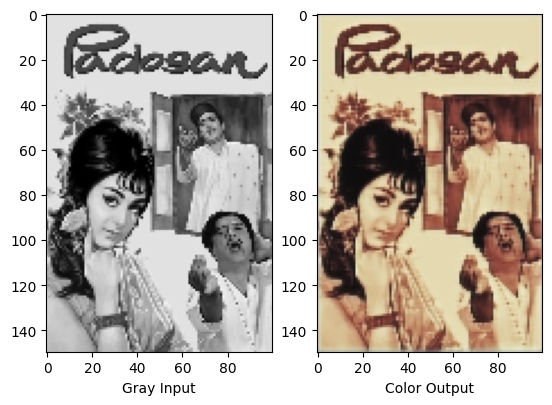

In [ ]:
# plot noisy image and generated image side by side
plt.subplot(1, 2, 1)
plt.imshow(test_color)
plt.xlabel('Gray Input')
plt.subplot(1, 2, 2)
plt.imshow(gen_output[0])
plt.xlabel('Color Output')


In [ ]:
color_images = generator.predict(color_images)

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step


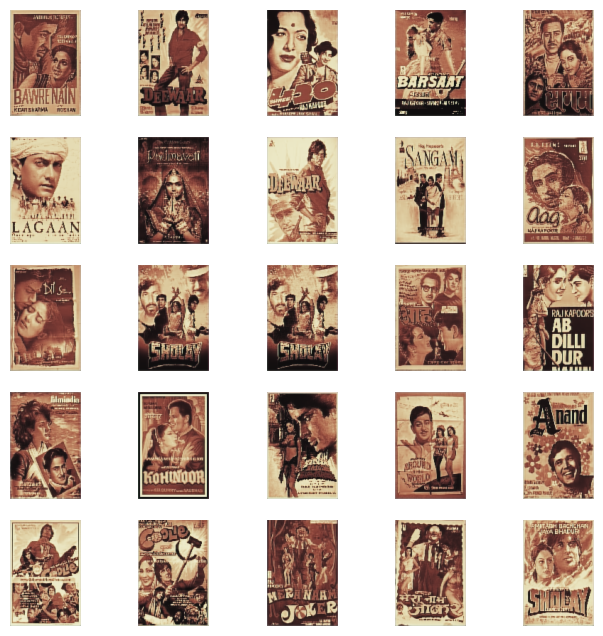

In [ ]:
plot_images(color_images)

In [ ]:
color_images.shape

(200, 150, 100, 3)

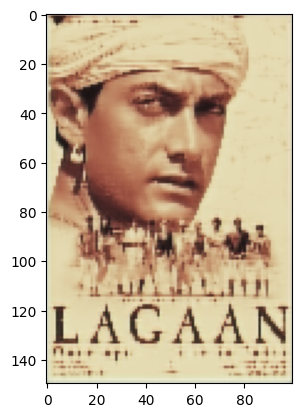

In [ ]:
plt.imshow(color_images[5])